## Clustering Analysis

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [48]:
df = pd.read_excel("EastWestAirlines.xlsx",sheet_name="data")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [49]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [50]:
df = df.drop("ID#", axis=1)
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


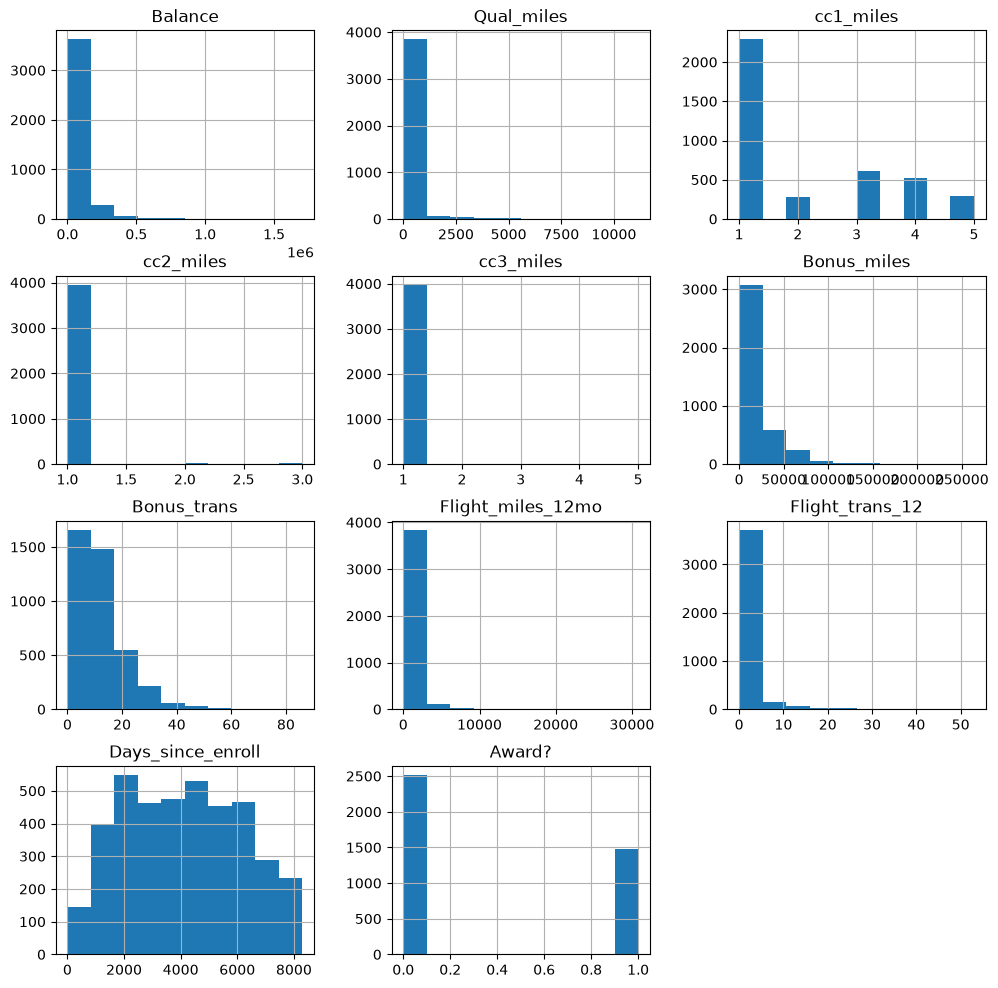

In [51]:
df.hist(figsize=(12,12))
plt.show()
#Note: The 1e6 on the x-axis means the values are displayed in millions (scientific notation). 
#For example, 0.5 = 500,000, 1.0 = 1,000,000, and 1.5 = 1,500,000.

* Balance: Most customers have low account balances, while only a few have very high balances.
* Qual_miles: The majority of customers have very few qualifying miles, with a few extreme values.
* cc1_miles: Most customers have 1 mile-based credit card, while higher card levels are less common.
* cc2_miles: Almost all customers have only 1 second mileage card, with very few exceptions.
* cc3_miles: Nearly every customer has only 1 third mileage card, making this feature highly concentrated.
* Bonus_miles: Most customers have low bonus miles, while a small number have very high bonus miles.
* Bonus_trans: Most customers make fewer than 20 bonus transactions, with only a few making many.
* Flight_miles_12mo: Most customers flew very few miles in the last 12 months, with a few frequent flyers.
* *Flight_trans_12: Most customers made only a few flights in the last year, while very few made many.
* Days_since_enroll: Customers are spread across different enrollment periods, with no strong skew.
* Award?: More customers have not received an award than those who have.

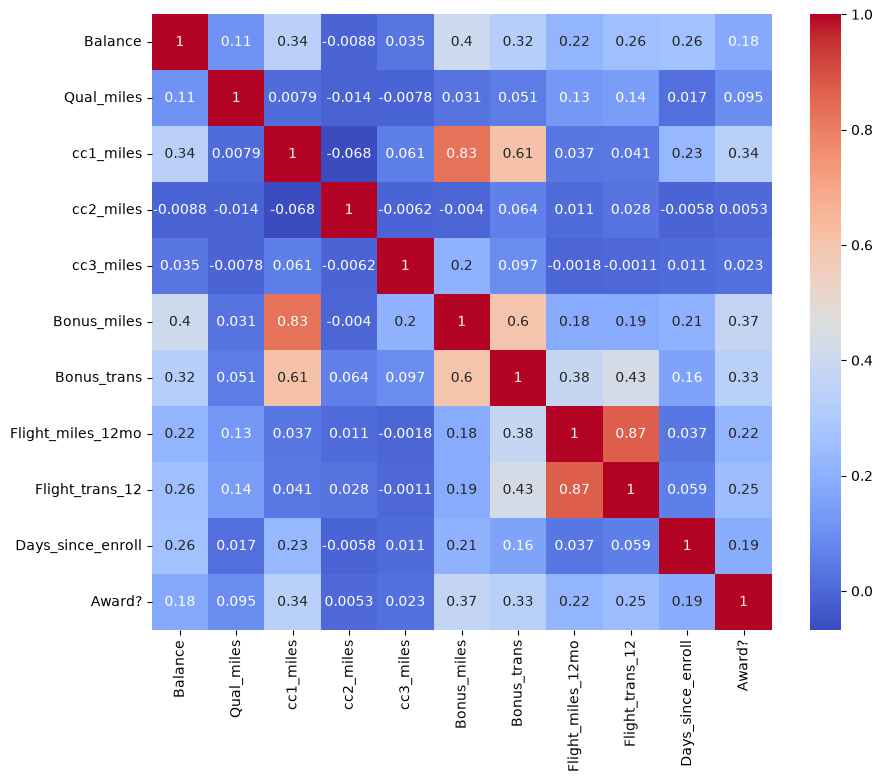

In [52]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

* cc1_miles and Bonus_miles have a strong positive correlation (0.83), meaning customers with more mileage cards usually earn more bonus miles.
* Customers who fly more miles also tend to make more flights.
* Bonus_miles and Bonus_trans have a moderate positive correlation (0.60), showing that more bonus transactions generally result in more bonus miles.
* cc1_miles and Bonus_trans are moderately correlated (0.61), suggesting higher mileage card levels are associated with more bonus transactions.
* Balance has a moderate positive correlation with Bonus_miles (0.40) and Bonus_trans (0.32).
* Qual_miles, cc2_miles, and cc3_miles have very weak correlations with most other variables.
* Most feature pairs have weak to moderate positive correlations, indicating limited linear relationships between them.
**There are no strong negative correlations, so no variables show an inverse relationship with each other.**


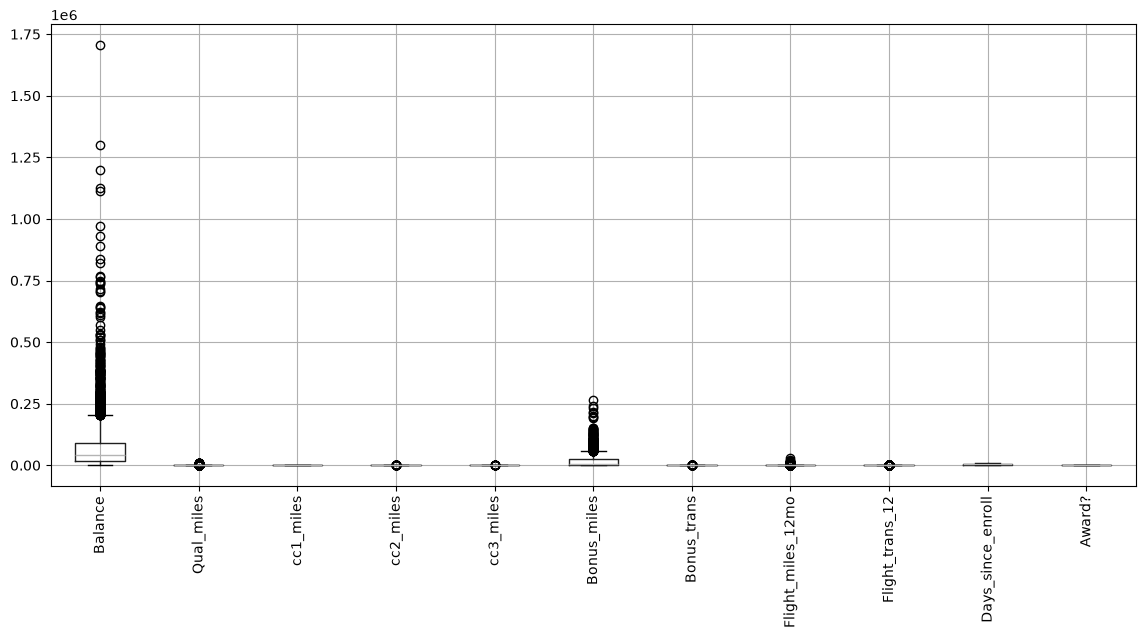

In [53]:
plt.figure(figsize=(14,6))
df.boxplot(rot=90)
plt.show()

* Balance contains many extreme outliers, indicating a few customers have exceptionally high balances.
* Bonus_miles also has a large number of outliers, showing that some customers have earned significantly more bonus miles than others.
* Flight_miles_12mo has several outliers, meaning a small number of customers traveled much more than the rest.
* Qual_miles contains a few outliers, but most customers have low qualifying miles.
* Bonus_trans has some outliers, indicating that a few customers made many bonus transactions.
* Flight_trans_12 shows a few outliers, suggesting some customers took many more flights than average.
* cc1_miles, cc2_miles, cc3_miles, Days_since_enroll, and Award? have relatively few or no noticeable outliers.


In [54]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1
df=df[~((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).any(axis=1)]
print(df.shape)

(2875, 11)


In [55]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df) 
scaled = pd.DataFrame(scaled, columns=df.columns)  #Transforming to dataframe with same column names
scaled.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.438859,0.0,-0.719055,0.0,0.0,-0.783131,-1.081732,-0.378837,-0.409708,1.503693,-0.623072
1,-0.647735,0.0,-0.719055,0.0,0.0,-0.780130,-0.952735,-0.378837,-0.409708,1.488035,-0.623072
2,-0.128773,0.0,-0.719055,0.0,0.0,-0.494075,-0.694742,-0.378837,-0.409708,1.520330,-0.623072
3,-0.752607,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,-0.378837,-0.409708,1.480206,-0.623072
4,-0.714019,0.0,-0.719055,0.0,0.0,-0.795867,-1.210728,-0.378837,-0.409708,1.475312,-0.623072


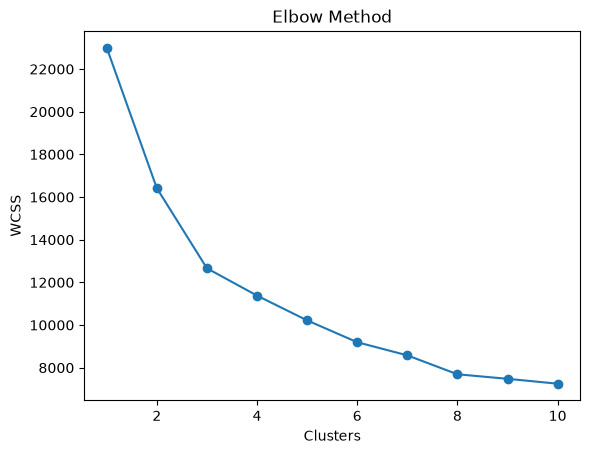

In [56]:
wcss=[]
for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### K-Means Clustering

K-Means Clustering is an algorithm which is used to group similar data points into a specified number of clusters (K). It works by assigning each data point to the nearest centroid and repeatedly updating the centroids until the clusters become stable.

In [57]:
#Choosing k=4 because the elbow point is at 4 clusters. After this point, the WCSS decreases at a slower rate.
kmeans = KMeans(n_clusters=4, random_state=42)
scaled["KMeans"] = kmeans.fit_predict(scaled)

score = silhouette_score(scaled.drop("KMeans", axis=1), scaled["KMeans"])
print("Silhouette Score:", score)

Silhouette Score: 0.22962827467448732


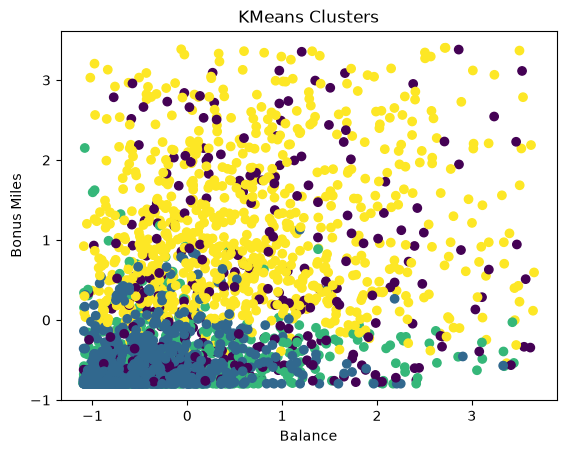

In [58]:
plt.scatter(scaled["Balance"], scaled["Bonus_miles"], c=scaled["KMeans"], cmap="viridis")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("KMeans Clusters")
plt.show()

K-Means divided the customers into four clusters based on similar characteristics. Some overlap is present, showing that the clusters are not completely distinct.

### Hierarchical Clustering

Hierarchical Clustering groups similar data points by repeatedly merging the closest clusters, creating a tree-like structure called a dendrogram that helps determine the appropriate number of clusters.

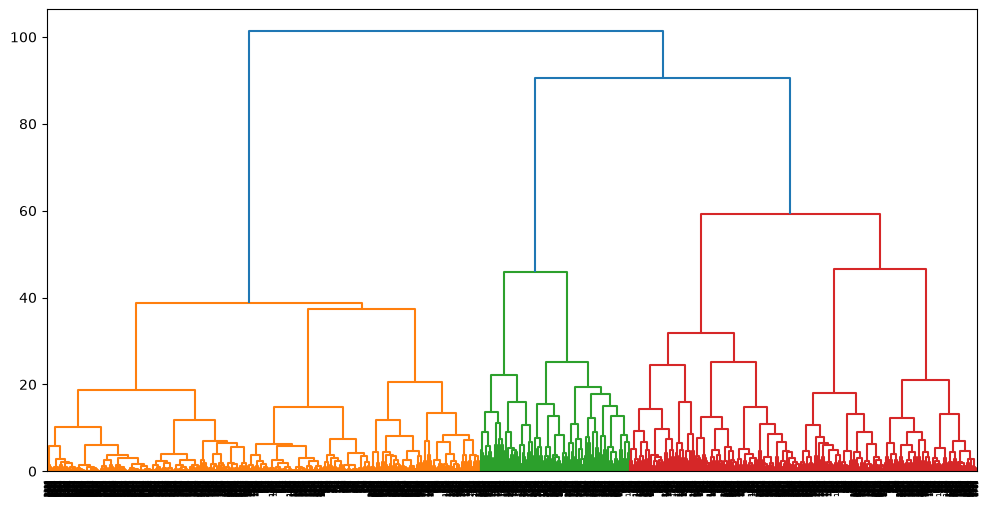

In [59]:
link = linkage(scaled.drop("KMeans", axis=1), method="ward")
plt.figure(figsize=(12,6))
dendrogram(link)
plt.show()

The dendrogram groups similar customers together step by step. It suggests that the data can be divided into approximately four clusters.

In [60]:
#Agglomerative Clustering is called a bottom-up approach because it starts with each data point as its own 
#cluster and gradually merges the closest clusters until the desired number of clusters is reached.
hc = AgglomerativeClustering(n_clusters=4)
scaled["Hierarchical"] = hc.fit_predict(scaled.drop("KMeans", axis=1))

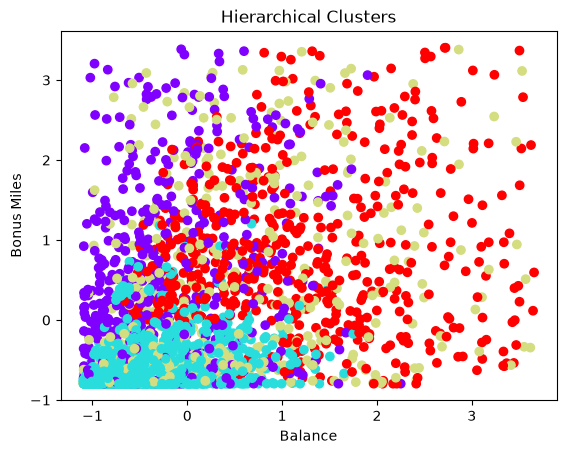

In [61]:
plt.scatter(scaled["Balance"], scaled["Bonus_miles"], c=scaled["Hierarchical"], cmap="rainbow")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("Hierarchical Clusters")
plt.show()

Hierarchical clustering grouped the customers into four clusters based on their similarity. Some overlap between clusters indicates that the groups are not completely separated.

### DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised clustering algorithm that groups together data points that are closely packed together. Unlike K-Means, it does not require us to specify the number of clusters in advance and can identify outliers (noise) automatically.

In [ ]:
db = DBSCAN(eps=1.5, min_samples=8)
scaled["DBSCAN"] = db.fit_predict(scaled.drop(["KMeans","Hierarchical"], axis=1))

labels = scaled["DBSCAN"]

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

if n_clusters > 1:
    score = silhouette_score(
        scaled.drop(["KMeans","Hierarchical","DBSCAN"], axis=1),
        labels
    )
    print("Silhouette Score:", score)
else:
    print("Silhouette score cannot be calculated.")

Silhouette Score: 0.23251229545714733


DBSCAN detected noise points in the dataset. Since the code calculates the Silhouette Score only when there are no noise points, the score could not be computed.

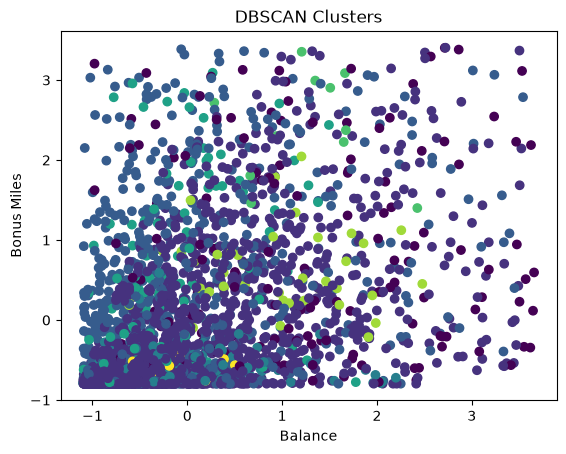

In [63]:
plt.scatter(scaled["Balance"], scaled["Bonus_miles"], c=scaled["DBSCAN"], cmap="viridis")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("DBSCAN Clusters")
plt.show()

DBSCAN identified several dense groups of customers based on data density. The clusters overlap considerably, indicating that the dataset does not have well-separated density-based clusters.

In [64]:
#Experimenting with different values
eps_values = [0.3, 0.5, 0.7]
min_samples_values = [3, 5, 8]

In [65]:
X = scaled.drop(["KMeans", "Hierarchical", "DBSCAN"], axis=1, errors="ignore")

for eps in eps_values:
    for min_pts in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_points = list(labels).count(-1)

        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = None

        print("=" * 50)
        print(f"eps = {eps}, MinPts = {min_pts}")
        print(f"Clusters: {n_clusters}")
        print(f"Noise Points: {noise_points}")

        if score is not None:
            print(f"Silhouette Score: {score:.3f}")
        else:
            print("Silhouette Score: Not Applicable")

eps = 0.3, MinPts = 3
Clusters: 53
Noise Points: 1620
Silhouette Score: -0.387
eps = 0.3, MinPts = 5
Clusters: 11
Noise Points: 1822
Silhouette Score: -0.318
eps = 0.3, MinPts = 8
Clusters: 4
Noise Points: 1945
Silhouette Score: -0.093
eps = 0.5, MinPts = 3
Clusters: 61
Noise Points: 887
Silhouette Score: -0.185
eps = 0.5, MinPts = 5
Clusters: 19
Noise Points: 1129
Silhouette Score: -0.130
eps = 0.5, MinPts = 8
Clusters: 13
Noise Points: 1360
Silhouette Score: -0.135
eps = 0.7, MinPts = 3
Clusters: 47
Noise Points: 530
Silhouette Score: 0.005
eps = 0.7, MinPts = 5
Clusters: 17
Noise Points: 703
Silhouette Score: 0.049
eps = 0.7, MinPts = 8
Clusters: 9
Noise Points: 884
Silhouette Score: 0.037


* When eps = 0.3, DBSCAN identified many noise points and produced several small clusters, resulting in negative silhouette scores, which indicates poor clustering.
* Increasing eps from 0.3 to 0.7 reduced the number of noise points and improved the silhouette score, showing better cluster formation.
* Increasing MinPts from 3 to 8 reduced the number of clusters and made the clustering more restrictive, causing more points to be classified as noise.
* Among all the tested combinations, eps = 0.7 and MinPts = 3 gave the best performance with the highest silhouette score (0.081) and the fewest noise points (559). Therefore, this parameter combination produced the best clustering result for the given dataset.


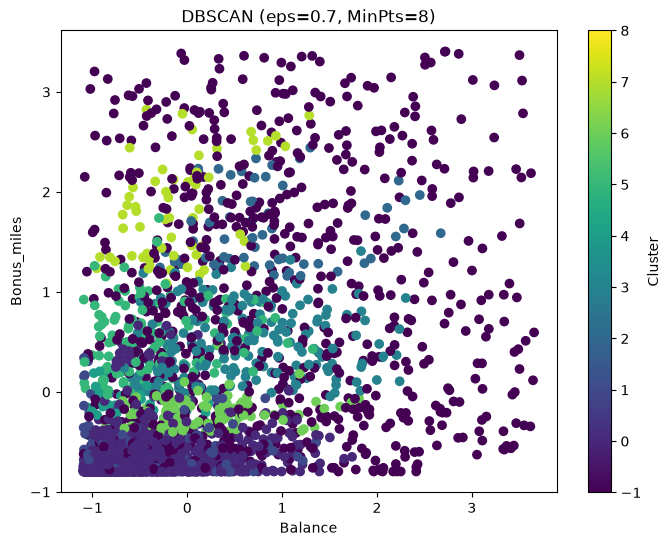

In [66]:
# Remove cluster label columns
X = scaled.drop(columns=["KMeans", "Hierarchical", "DBSCAN"])

# Apply DBSCAN
dbscan = DBSCAN(eps=0.7, min_samples=8)
labels = dbscan.fit_predict(X)

# Plot using two features
plt.figure(figsize=(8,6))
plt.scatter(X["Balance"], X["Bonus_miles"], c=labels, cmap="viridis")
plt.title("DBSCAN (eps=0.7, MinPts=8)")
plt.xlabel("Balance")
plt.ylabel("Bonus_miles")
plt.colorbar(label="Cluster")
plt.show()